# Hands-on 6 — NIFTy.cl: domains, fields and operators

**Course:** NIFTy in a day · **Session:** 17:45 – 18:30

`nifty.cl` ("classical NIFTy") is the original, object-oriented flavour. You'll meet it in many published
pipelines and papers, and its explicit design teaches IFT concepts very cleanly: **domains** know their geometry,
**fields** carry their domain, **operators** know their domain, target and adjoint. Everything you did in
`nifty.re` has a counterpart here.

**You will learn**
1. Domains (`RGSpace`, `HPSpace`, `PowerSpace`, `UnstructuredDomain`, `DomainTuple`, `MultiDomain`) and fields (`ift.Field`, `MultiField`).
2. Linear operators: composition with `@`, `.adjoint`, `.inverse`, writing your own, and testing it.
3. The Wiener filter written *literally* as $D = (S^{-1} + R^\dagger N^{-1}R)^{-1}$.
4. Non-linear models with `ift.SimpleCorrelatedField` and `ift.optimize_kl`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import nifty.cl as ift

ift.random.push_sseq_from_seed(42)          # nifty.cl has a global, seedable RNG stack
plt.rcParams["figure.dpi"] = 90

## 1. Domains and fields

A **domain** describes *where* a field lives — shape, pixel volume, harmonic partner. A **field** is an array
**bound to its domain**; operations check domains, which catches whole classes of bugs.

In [2]:
x_space = ift.RGSpace(256, distances=1 / 256)       # 1-D regular grid on [0, 1)
k_space = x_space.get_default_codomain()             # its harmonic partner
print(x_space)
print(k_space)
print("pixel volume dvol:", x_space.dvol, " total volume:", x_space.total_volume)

sphere = ift.HPSpace(16)                             # HEALPix sphere, nside=16
print(sphere, " pixels:", sphere.size)

f = ift.Field.from_raw(x_space, np.sin(2 * np.pi * np.linspace(0, 1, 256, endpoint=False)) ** 2)
print("sum of values :", f.s_sum())
print("integral ∫f dx:", f.s_integrate(), "  (= sum * dvol, resolution independent)")

g = ift.from_random(x_space, "normal")               # a white-noise field
print("field arithmetic keeps the domain:", (f + 2 * g).domain)

# Multi-component inputs live on a MultiDomain → MultiField (like the dict-of-arrays in nifty.re)
md = ift.MultiDomain.make({"a": x_space, "b": ift.UnstructuredDomain(3)})
mf = ift.from_random(md)
print("MultiField keys:", list(mf.keys()))

RGSpace(shape=(256,), distances=(0.00390625,), harmonic=False)
RGSpace(shape=(256,), distances=(np.float64(1.0),), harmonic=True)
pixel volume dvol: 0.00390625  total volume: 1.0
HPSpace(nside=16)  pixels: 3072
sum of values : 128.0
integral ∫f dx: 0.5   (= sum * dvol, resolution independent)
field arithmetic keeps the domain: DomainTuple, len: 1
* RGSpace(shape=(256,), distances=(0.00390625,), harmonic=False)
MultiField keys: ['a', 'b']


## 2. Linear operators

Every operator has a `domain`, a `target`, and `apply(x, mode)` for `TIMES`, `ADJOINT_TIMES`
(and optionally `INVERSE_TIMES`, `ADJOINT_INVERSE_TIMES`). Composition `A @ B`, sums, scalar multiples,
`.adjoint` and `.inverse` build new operators lazily — nothing is ever stored as a matrix.

In [3]:
HT = ift.HarmonicTransformOperator(k_space, target=x_space)   # harmonic → position
print("HT:", HT.domain[0].harmonic, "→", HT.target[0].harmonic)

# Prior covariance S: diagonal S_k in harmonic space, "sandwiched" by the (invertible) Hartley transform F:
#     S = F^† S_k F        (SandwichOperator.make(bun=F, cheese=S_k) builds exactly bun^† @ cheese @ bun)
def pow_spec(k):
    return 2000.0 / (1.0 + (k / 8.0) ** 4)

F = ift.HartleyOperator(x_space)                     # position → harmonic
S_k = ift.create_power_operator(F.target, power_spectrum=pow_spec, sampling_dtype=float)
S = ift.SandwichOperator.make(bun=F, cheese=S_k)     # knows how to draw samples and to invert itself
print(S)

HT: True → False
SandwichOperator:
  Cheese:
  DiagonalOperator (domain/target shape: (256,), sampling dtype <class 'float'>)
  Bun:
  HartleyOperator


### Writing your own linear operator
Here: a **box-car smoothing** operator (a simple instrument blur). For a linear operator you must implement both
directions; `ift.extra.check_linear_operator` then verifies numerically that $\langle Ax, y\rangle = \langle x, A^\dagger y\rangle$,
that the operator is linear, etc. **Always run it** on custom operators — wrong adjoints are the #1 source of silent errors.

In [4]:
class BoxBlur(ift.LinearOperator):
    def __init__(self, domain, width):
        self._domain = ift.DomainTuple.make(domain)
        self._target = self._domain
        self._capability = self.TIMES | self.ADJOINT_TIMES
        self._w = width

    def apply(self, x, mode):
        self._check_input(x, mode)
        v = x.asnumpy()
        out = sum(np.roll(v, s) for s in range(-self._w, self._w + 1)) / (2 * self._w + 1)
        # A symmetric kernel is self-adjoint; for an asymmetric one, ADJOINT_TIMES would use the mirrored shifts.
        return ift.makeField(self._tgt(mode), out)

B = BoxBlur(x_space, 5)
ift.extra.check_linear_operator(B)
print("BoxBlur passed the adjointness/linearity tests ✓")

BoxBlur passed the adjointness/linearity tests ✓


## 3. The Wiener filter, written exactly like the formula

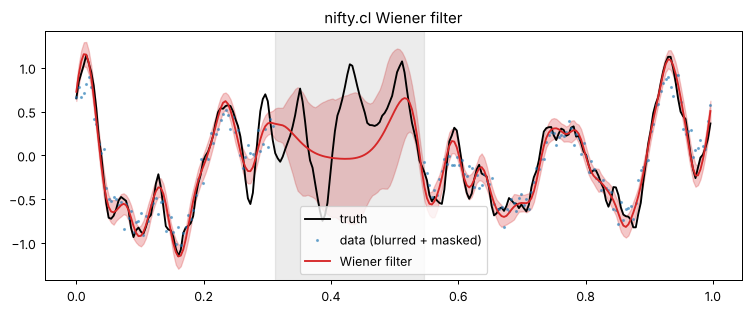

In [5]:
mask = np.ones(256, bool); mask[80:140] = False
M = ift.MaskOperator(ift.makeField(x_space, ~mask))      # MaskOperator removes the flagged pixels
R = M @ B                                                 # response: blur, then mask
N = ift.ScalingOperator(R.target, 0.01, float)            # noise covariance (variance 0.01, std 0.1)

s_true = S.draw_sample()
d = R(s_true) + N.draw_sample()

j = R.adjoint(N.inverse(d))                               # information source
ic = ift.GradientNormController(iteration_limit=2000, tol_abs_gradnorm=1e-5)
D_inv = R.adjoint @ N.inverse @ R + S.inverse             # inverse propagator
D = ift.InversionEnabler(D_inv, ic, approximation=S.inverse).inverse
m = D(j)                                                  # posterior mean (CG under the hood)

# posterior samples: SamplingEnabler lets D draw samples via CG
D_s = ift.SamplingEnabler(ift.SandwichOperator.make(bun=R, cheese=N.inverse), S.inverse, ic, S.inverse)
D_s = ift.InversionEnabler(D_s, ic).inverse
sc = ift.StatCalculator()
for _ in range(30):
    sc.add(m + D_s.draw_sample())
std = sc.var.sqrt()

xs = np.linspace(0, 1, 256, endpoint=False)
plt.figure(figsize=(10, 3.6))
plt.plot(xs, s_true.asnumpy(), "k", label="truth")
data_plot = M.adjoint(d).asnumpy_rw(); data_plot[~mask] = np.nan
plt.plot(xs, data_plot, ".", ms=3, alpha=0.5, label="data (blurred + masked)")
plt.plot(xs, m.asnumpy(), "C3", label="Wiener filter")
plt.fill_between(xs, (m - std).asnumpy(), (m + std).asnumpy(), color="C3", alpha=0.25)
plt.axvspan(80 / 256, 140 / 256, color="grey", alpha=0.15); plt.legend(); plt.title("nifty.cl Wiener filter"); plt.show()

## 4. Non-linear models: operators on MultiFields, `SimpleCorrelatedField`, `optimize_kl`

Non-linear operators (`ift.Operator`) map (Multi)Fields to Fields and are composed the same way. They are
evaluated on `ift.Linearization` objects to get Jacobians automatically — the `nifty.cl` analogue of JAX autodiff.
Pointwise non-linearities are methods: `.exp()`, `.sigmoid()`, `.log()`, `.clip()`, …

Operator domain has more than 4 keys.


Check derivatives only with one constant key at a time.


Sampling: Iteration #0 energy=3.228393E+05 diff=3.228393E+05 crit=5.0E-02 clvl=0


Sampling: Iteration #1 energy=2.081498E+04 diff=3.020243E+05 crit=5.0E-02 clvl=0


model input  (latent MultiDomain): ['asperity', 'flexibility', 'fluctuations', 'loglogavgslope', 'spectrum', 'xi', 'zeromode']
model output: DomainTuple, len: 1
* RGSpace(shape=(64, 64), distances=(np.float64(0.015625), np.float64(0.015625)), harmonic=False)
Jacobian of the model checked ✓


...

Newton: Iteration #8 energy=2.659663E+03 diff=1.124386E+00 crit=5.0E-01 clvl=0


Newton: Iteration #9 energy=2.659662E+03 diff=1.238672E-04 crit=5.0E-01 clvl=1


Newton: Iteration #10 energy=2.659602E+03 diff=6.087801E-02 crit=5.0E-01 clvl=2


                     reduced χ²          mean      # dof # ign. dof
-------------------------------------------------------------------
Data residuals
  <None>              1.3 ± 0.2    -0.0 ± 0.1        200          -
Latent space
  asperity            1.3 ± 1.3    -0.9 ± 0.6          1          -
  flexibility         1.9 ± 1.6     0.3 ± 1.4          1          -
  fluctuations        2.1 ± 1.7     1.3 ± 0.6          1          -
  loglogavgslope      0.6 ± 0.9    -0.2 ± 0.8          1          -
  spectrum            1.0 ± 0.0    -0.0 ± 0.0        910          -
  xi                  1.0 ± 0.0    -0.0 ± 0.0       4096          -
  zeromode            1.0 ± 1.1    -0.0 ± 1.1          1          -


Task 0
* apply: 		      0
* apply Linearization: 	   2931
* Jacobian: 		   4251
* Adjoint Jacobian: 	   4477


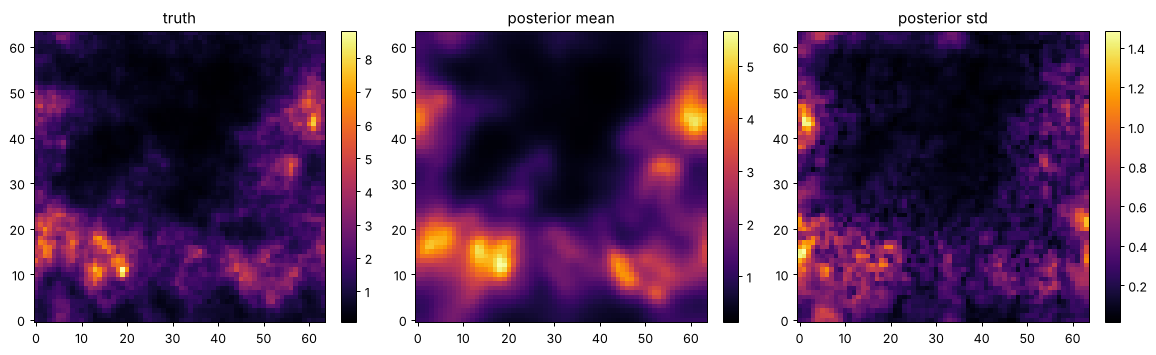

In [6]:
space2 = ift.RGSpace([64, 64])
cf = ift.SimpleCorrelatedField(space2, offset_mean=0.0, offset_std=(1e-3, 1e-6),
                               fluctuations=(1.0, 0.2), loglogavgslope=(-4.0, 0.5),
                               flexibility=(0.5, 0.2), asperity=(0.2, 0.1))
signal = cf.exp()                                          # log-normal field (a non-linear operator)
print("model input  (latent MultiDomain):", list(signal.domain.keys()))
print("model output:", signal.target)

ift.extra.check_operator(signal, ift.from_random(signal.domain) * 0.1, ntries=2)   # checks the Jacobian numerically
print("Jacobian of the model checked ✓")

# Response: 200 random lines of sight (cl's LOSResponse)
rng = ift.random.current_rng()
R2 = ift.LOSResponse(space2, starts=list(rng.random((200, 2)).T), ends=list(rng.random((200, 2)).T))
signal_response = R2 @ signal
N2 = ift.ScalingOperator(R2.target, 1e-4, float)

mock = ift.from_random(signal_response.domain, "normal")
d2 = signal_response(mock) + N2.draw_sample()

likelihood_energy = ift.GaussianEnergy(d2, inverse_covariance=N2.inverse) @ signal_response

ic_sampling = ift.AbsDeltaEnergyController(name="Sampling", deltaE=0.05, iteration_limit=100)
ic_newton = ift.AbsDeltaEnergyController(name="Newton", deltaE=0.5, convergence_level=2, iteration_limit=20)
ic_sampling_nl = ift.AbsDeltaEnergyController(name="NL sampling", deltaE=0.5, iteration_limit=10, convergence_level=2)

samples = ift.optimize_kl(
    likelihood_energy, total_iterations=5, n_samples=lambda i: 2 if i < 2 else 5,
    kl_minimizer=ift.NewtonCG(ic_newton), sampling_iteration_controller=ic_sampling,
    nonlinear_sampling_minimizer=ift.NewtonCG(ic_sampling_nl),
    output_directory=None, plot_energy_history=False, plot_minisanity_history=False,
)
mean, var = samples.sample_stat(signal)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (t, fld) in zip(axs, [("truth", signal(mock)), ("posterior mean", mean), ("posterior std", var.sqrt())]):
    h = ax.imshow(fld.asnumpy().T, origin="lower", cmap="inferno"); ax.set_title(t); plt.colorbar(h, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 5. `nifty.cl` vs `nifty.re` — the translation table

| Task | `nifty.cl` | `nifty.re` |
|---|---|---|
| Geometry | `ift.RGSpace(shape, distances)`, `ift.HPSpace(nside)` | `distances=` args; `make_grid` |
| Data container | `ift.Field`, `ift.MultiField` | JAX array, dict of arrays (pytree), `jft.Vector` |
| Model | compose `ift.Operator`s: `R @ cf.exp()` | subclass `jft.Model`, write `__call__` |
| Derivatives | `ift.Linearization` (built-in) | JAX `grad`, `jvp`, `vjp` |
| Adjoint of linear ops | you implement it, `check_linear_operator` | automatic (`jax.vjp`) |
| Correlated field | `ift.SimpleCorrelatedField`, `ift.CorrelatedFieldMaker` | `jft.CorrelatedFieldMaker` |
| Likelihood | `ift.GaussianEnergy(d, N.inverse) @ model`, `ift.PoissonianEnergy` | `jft.Gaussian(d, ...).amend(model)`, `jft.Poissonian` |
| VI | `ift.optimize_kl(energy, iters, n_samples, minimizer, ic, ...)` | `jft.optimize_kl(lh, pos, key=, ...)` |
| Iteration control | `ift.AbsDeltaEnergyController`, `GradientNormController` | `xtol`, `absdelta`, `maxiter` kwargs |
| Posterior stats | `samples.sample_stat(op)` | `jft.mean_and_std(tuple(op(s) for s in samples))` |
| Parallelism | MPI (`comm=`) over samples | `jax.vmap` / multiple devices (`devices=`) |
| Speed | numpy (+ducc0), optional cupy | XLA JIT on CPU/GPU — usually faster |

**Rule of thumb:** new projects → `nifty.re`. Use `nifty.cl` when you need its operator library (e.g. its
radio-interferometry/LOS/sphere operators in existing pipelines) or when maintaining older code.

## ✏️ Exercises
**E6.1** Make `BoxBlur` asymmetric (shifts 0…w only) and run `check_linear_operator` — watch it fail; then fix the adjoint.

**E6.2** Port the 1-D correlated-field inference of Hands-on 3 to `nifty.cl` using `ift.SimpleCorrelatedField(ift.RGSpace(256), ...)` and a `MaskOperator`.

**E6.3** Put the Wiener filter of §3 on the **sphere**: `x_space = ift.HPSpace(32)`, use `HT = ift.HarmonicTransformOperator(x_space.get_default_codomain(), x_space)`, a random mask, and plot with `ift.Plot`.

In [7]:
# Your work here

---
## Solutions

In [8]:
# E6.1 — asymmetric blur needs mirrored shifts in the adjoint
class CausalBlur(ift.LinearOperator):
    def __init__(self, domain, width):
        self._domain = ift.DomainTuple.make(domain); self._target = self._domain
        self._capability = self.TIMES | self.ADJOINT_TIMES; self._w = width

    def apply(self, x, mode):
        self._check_input(x, mode)
        v = x.asnumpy()
        sign = 1 if mode == self.TIMES else -1          # adjoint of a shift is the opposite shift
        out = sum(np.roll(v, sign * s) for s in range(self._w + 1)) / (self._w + 1)
        return ift.makeField(self._tgt(mode), out)

ift.extra.check_linear_operator(CausalBlur(x_space, 4))
print("CausalBlur adjoint correct ✓")

CausalBlur adjoint correct ✓
